In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv("CrimesOnWomenData.csv")
df.head()

,Unnamed: 0,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT
0,0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7
1,1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0
2,2,ASSAM,2001,817,1070,59,850,4,1248,0
3,3,BIHAR,2001,888,518,859,562,21,1558,83
4,4,CHHATTISGARH,2001,959,171,70,1763,161,840,0


## Data Cleaning

In [3]:
#Removing Unnecessary column
df.drop(columns='Unnamed: 0',inplace=True)

In [4]:
#Rename columns
df.rename(columns={
    'K&A':'Kidnapping_Abduction',
    'DD':'Dowry_Deaths',
    'AoW':'Assault_on_Women',
    'AoM':'Assault_on_Minors',
    'DV':'Domestic_Violence',
    'WT':'Women_Trafficking'
}, inplace=True)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   State                 736 non-null    str  
 1   Year                  736 non-null    int64
 2   Rape                  736 non-null    int64
 3   Kidnapping_Abduction  736 non-null    int64
 4   Dowry_Deaths          736 non-null    int64
 5   Assault_on_Women      736 non-null    int64
 6   Assault_on_Minors     736 non-null    int64
 7   Domestic_Violence     736 non-null    int64
 8   Women_Trafficking     736 non-null    int64
dtypes: int64(8), str(1)
memory usage: 51.9 KB


In [6]:
df.isnull().sum()

State                   0
Year                    0
Rape                    0
Kidnapping_Abduction    0
Dowry_Deaths            0
Assault_on_Women        0
Assault_on_Minors       0
Domestic_Violence       0
Women_Trafficking       0
dtype: int64

In [7]:
#The statistical summary helps understand the distribution and scale of crime categories across states and years
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,736.0,2011.149457,6.053453,2001.0,2006.00,2011.0,2016.00,2021.0
Rape,736.0,727.855978,977.024945,0.0,35.00,348.5,1069.00,6337.0
Kidnapping_Abduction,736.0,1134.542120,1993.536828,0.0,24.75,290.0,1216.00,15381.0
Dowry_Deaths,736.0,215.692935,424.927334,0.0,1.00,29.0,259.00,2524.0
Assault_on_Women,736.0,1579.115489,2463.962518,0.0,34.00,387.5,2122.25,14853.0
Assault_on_Minors,736.0,332.722826,806.024551,0.0,3.00,31.0,277.50,9422.0
Domestic_Violence,736.0,2595.078804,4042.004953,0.0,13.00,678.5,3545.00,23278.0
Women_Trafficking,736.0,28.744565,79.999660,0.0,0.00,0.0,15.00,549.0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['State'].nunique()

70

In [10]:
df['State']=df['State'].str.title()
df['State'].unique()

<StringArray>
[   'Andhra Pradesh', 'Arunachal Pradesh',             'Assam',
             'Bihar',      'Chhattisgarh',               'Goa',
           'Gujarat',           'Haryana',  'Himachal Pradesh',
   'Jammu & Kashmir',         'Jharkhand',         'Karnataka',
            'Kerala',    'Madhya Pradesh',       'Maharashtra',
           'Manipur',         'Meghalaya',           'Mizoram',
          'Nagaland',            'Odisha',            'Punjab',
         'Rajasthan',            'Sikkim',        'Tamil Nadu',
           'Tripura',     'Uttar Pradesh',       'Uttarakhand',
       'West Bengal',     'A & N Islands',        'Chandigarh',
      'D & N Haveli',       'Daman & Diu',       'Lakshadweep',
        'Puducherry',         'Telangana',        'D&N Haveli',
          'Delhi Ut']
Length: 37, dtype: str

In [11]:
df['State'] = df['State'].replace({
    'Delhi UT':'Delhi',
    'D & N Haveli':'Dadra and Nagar Haveli',
    'D&N Haveli': 'Dadra and Nagar Haveli',
    'A & N Islands':'Andaman and Nicobar Islands',
    'Andaman And Nicobar':'Andaman And Nicobar Islands'
})

In [12]:
df['State'].unique()

<StringArray>
[             'Andhra Pradesh',           'Arunachal Pradesh',
                       'Assam',                       'Bihar',
                'Chhattisgarh',                         'Goa',
                     'Gujarat',                     'Haryana',
            'Himachal Pradesh',             'Jammu & Kashmir',
                   'Jharkhand',                   'Karnataka',
                      'Kerala',              'Madhya Pradesh',
                 'Maharashtra',                     'Manipur',
                   'Meghalaya',                     'Mizoram',
                    'Nagaland',                      'Odisha',
                      'Punjab',                   'Rajasthan',
                      'Sikkim',                  'Tamil Nadu',
                     'Tripura',               'Uttar Pradesh',
                 'Uttarakhand',                 'West Bengal',
 'Andaman and Nicobar Islands',                  'Chandigarh',
      'Dadra and Nagar Haveli',          

## Feature Engineering

In [13]:
df['Total_cases']=df[['Rape', 'Kidnapping_Abduction', 'Dowry_Deaths',
       'Assault_on_Women', 'Assault_on_Minors', 'Domestic_Violence',
       'Women_Trafficking']].sum(axis=1)

## Data Analysis

### ResearchQeus 1.Which states report the highest and lowest total crimes?

In [14]:
states_total_crime=df.groupby('State').agg({'Total_cases':'sum'})
highest_crime_state=states_total_crime.sort_values("Total_cases",ascending=False).head(10)
lowest_crime_state=states_total_crime.sort_values("Total_cases").head(10)

In [15]:
highest_crime_state

,Total_cases
State,
Uttar Pradesh,529734
Madhya Pradesh,413157
West Bengal,409242
Andhra Pradesh,391123
Rajasthan,379264
Maharashtra,365632
Assam,291980
Kerala,202986
Odisha,194774


In [16]:
lowest_crime_state

,Total_cases
State,
Lakshadweep,72
Puducherry,1793
Andaman and Nicobar Islands,1868
Mizoram,2844
Goa,4179
Meghalaya,4294
Manipur,4390
Arunachal Pradesh,4822
Chandigarh,5341


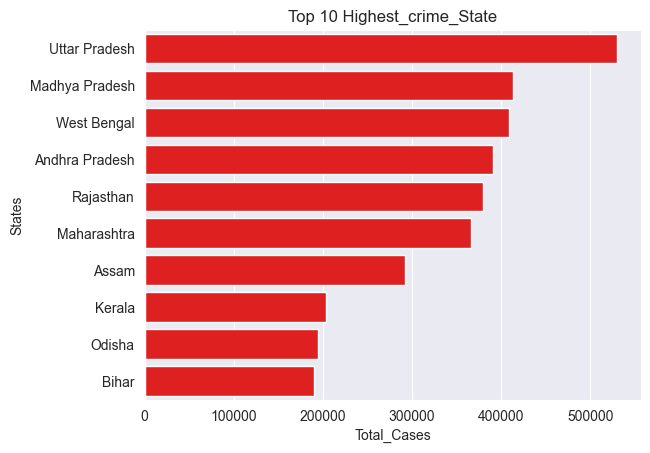

In [17]:
sns.barplot(data=highest_crime_state,x='Total_cases',
             y='State',color='red')
plt.xlabel('Total_Cases')
plt.ylabel('States')
plt.title('Top 10 Highest_crime_State')

plt.show()

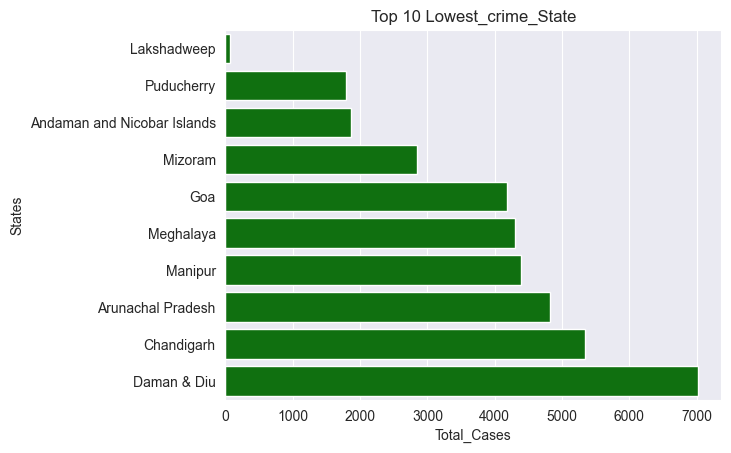

In [18]:
sns.barplot(data=lowest_crime_state,x='Total_cases',y='State',color='green')
plt.xlabel('Total_Cases')
plt.ylabel('States')
plt.title('Top 10 Lowest_crime_State')

plt.show()

## Insights
  - Uttar Pradesh reported the highest total crime cases, followed by Madhya Pradesh and West Bengal.

  - Lakshadweep recorded the lowest number of total crime cases among all states and union territories.

  - Large and densely populated states such as Uttar Pradesh, Madhya Pradesh, and Maharashtra showed significantly higher reported crime counts.

  - Several northeastern states and smaller union territories reported comparatively lower crime cases.

## ResearchQues 2: Which year recorded the highest crime activity?

In [19]:
year_grouped=df.groupby('Year').agg({'Total_cases':'sum'})
year_grouped.head()

,Total_cases
Year,
2001,128537
2002,128972
2003,128142
2004,140072
2005,139333


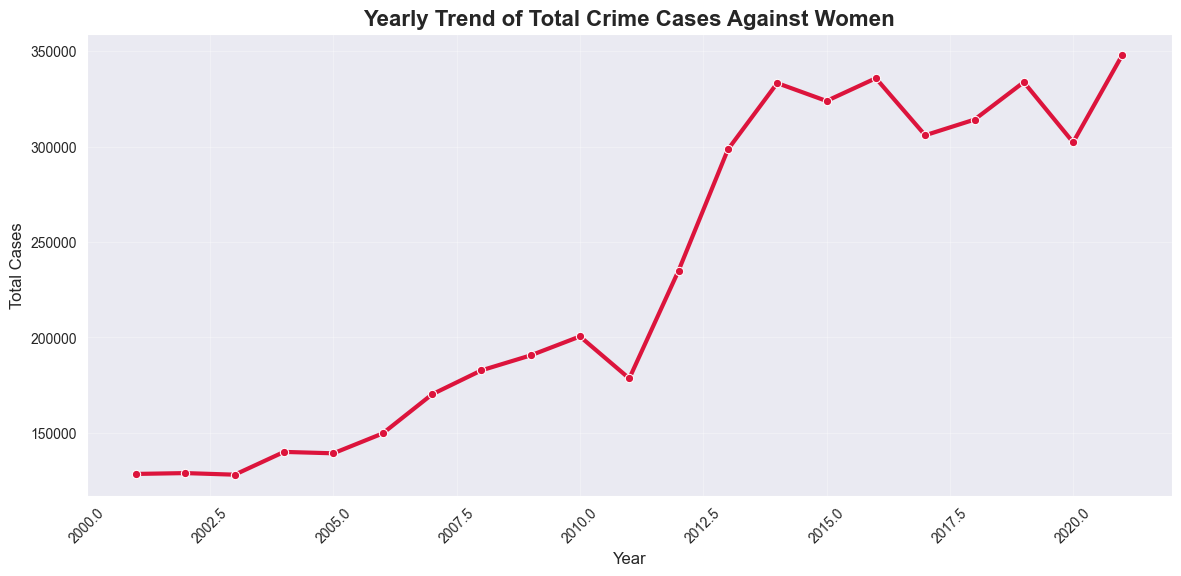

In [20]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=year_grouped,
    x='Year',
    y='Total_cases',
    marker='o',
    linewidth=3,
    color='crimson'
)

plt.title('Yearly Trend of Total Crime Cases Against Women',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Year',fontsize=12)
plt.ylabel('Total Cases',fontsize=12)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

## Insights
 - From 2000 to 2010 , total crime cases against women showed a steady upward trend across India.
 - A slight declined was observed between 2010 and 2011.
 - Crime cases increased sharply from 2012 to 2015 , reaching one of the highest levels during entire period.

## ResearchQues 3: Which crime category contributes most to total crimes?


In [21]:
crime_column=df.iloc[:,2:9]

In [36]:
crime_total=crime_column.sum()
crime_total=crime_total.sort_values(ascending=False).reset_index()
crime_total.columns=["Category","TotalCases"]
crime_total

,Category,TotalCases
0,Domestic_Violence,1909978
1,Assault_on_Women,1162229
2,Kidnapping_Abduction,835023
3,Rape,535702
4,Assault_on_Minors,244884
5,Dowry_Deaths,158750
6,Women_Trafficking,21156


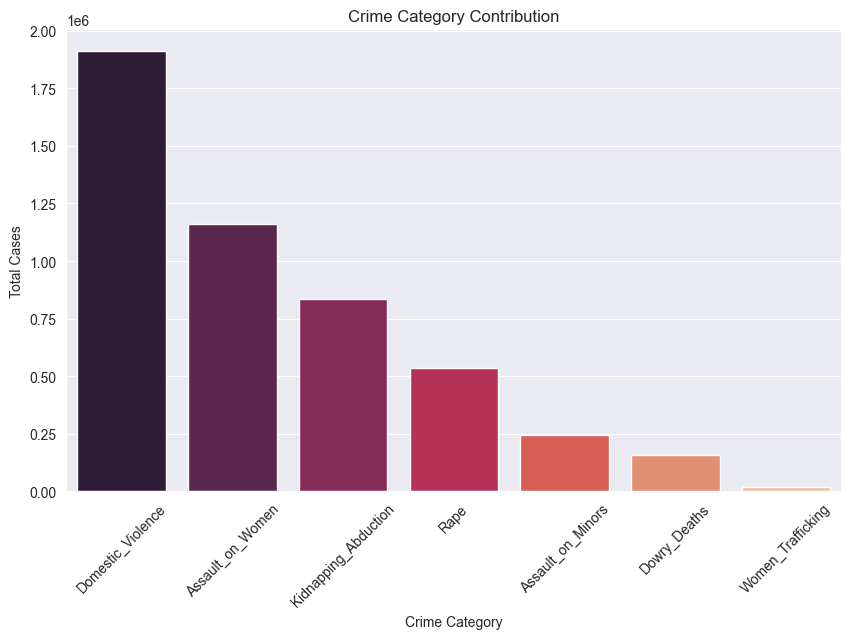

In [23]:
plt.figure(figsize=(10,6))

ax=sns.barplot(crime_total,x='Category',y='TotalCases',palette='rocket',hue='Category')

plt.title('Crime Category Contribution')
plt.xlabel('Crime Category')
plt.ylabel('Total Cases')
plt.xticks(rotation=45)

plt.show()

### Insights

- Domestic Violence contributed the highest share among all crime categories, accounting for ~40% of total reported crime cases.

- Women Trafficking recorded the lowest number of reported cases among all categories.

- The large contribution of domestic violence indicates that household-related violence remains a major concern across India.

## ResearchQues 4: How has assault on minors changed over time?


In [24]:
minors_assault=df.groupby('Year').agg(Total_case=('Assault_on_Minors','sum')).reset_index()
minors_assault

,Year,Total_case
0,2001,9656
1,2002,10027
2,2003,12220
3,2004,9871
4,2005,9759
5,2006,9822
6,2007,10783
7,2008,12084
8,2009,10891
9,2010,9881


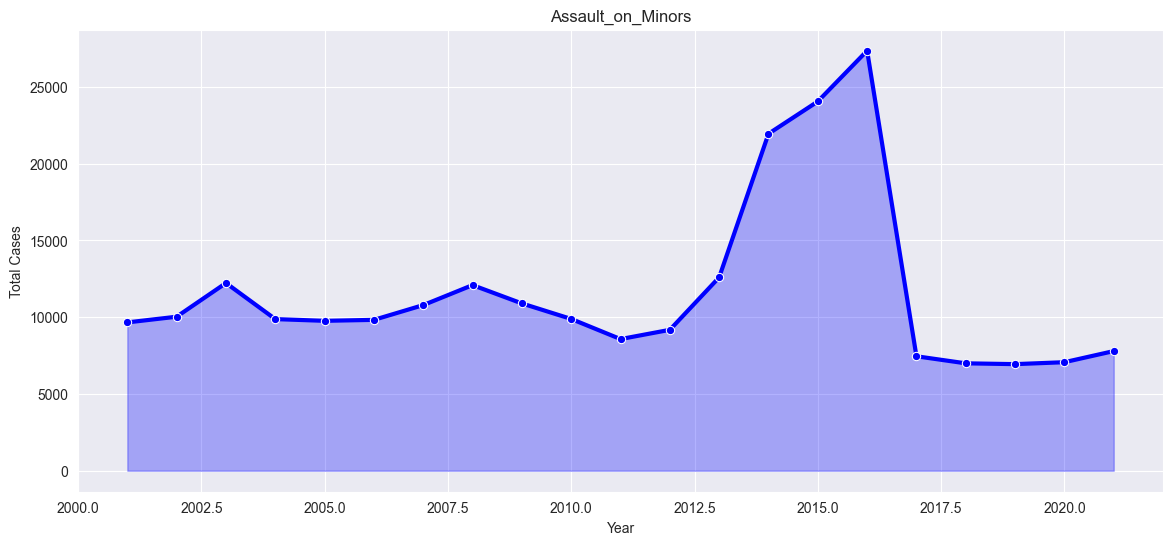

In [25]:
plt.figure(figsize=(14,6))

sns.lineplot(data=minors_assault,
            x='Year',
            y='Total_case',
            marker='o',
            linewidth=3,
             color='blue')

plt.fill_between(
    minors_assault['Year'],
    minors_assault['Total_case'],
    alpha=0.3,
    color='blue'
)

plt.title('Assault_on_Minors')
plt.xlabel('Year')
plt.ylabel('Total Cases')
# plt.xticks(rotation=45)

plt.show()

### Insights

- Assault on minors remained relatively stable between 2001 and 2012.

- A sharp increase was observed from 2013 to 2016, with cases reaching peak levels during this period.

- After 2016, reported cases dropped significantly and remained comparatively lower in subsequent years.

- The trend suggests that assault on minors experienced sudden fluctuations rather than a steady long-term increase.

## ResearchQues 5: Is domestic violence associated with assault on women?

In [26]:
relation=df[['Domestic_Violence','Assault_on_Women']].corr()

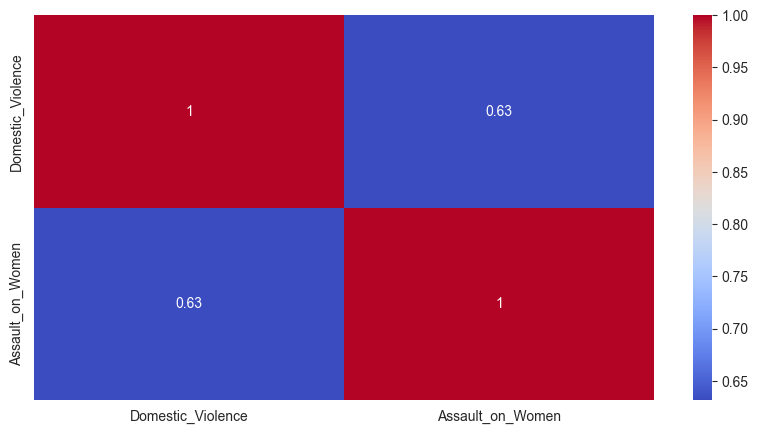

In [27]:
plt.figure(figsize=(10,5))

sns.heatmap(data=relation,annot=True,cmap='coolwarm')
plt.show()

### Insights

- Domestic Violence and Assault on Women showed a moderate positive correlation of 0.63.

- This indicates that states reporting higher domestic violence cases also tend to report higher assault on women cases.

- The relationship suggests a possible association between the two crime categories, although correlation does not confirm direct causation.

## ResearchQues 6 :Do a few states contribute to most crime cases?

In [40]:
state_crime=df.groupby('State').agg(Total_case=('Total_cases','sum')).reset_index()
state_crime.head()

,State,Total_case
0,Andaman and Nicobar Islands,1868
1,Andhra Pradesh,391123
2,Arunachal Pradesh,4822
3,Assam,291980
4,Bihar,189886


In [41]:
overall_total=state_crime['Total_case'].sum()
overall_total

np.int64(4867722)

In [42]:
state_crime['contribution%']=(state_crime['Total_case']/overall_total)*100

In [43]:
top10_states=state_crime.sort_values('contribution%',ascending=False).head(10)
top10_states

,State,Total_case,contribution%
33,Uttar Pradesh,529734,10.882585
19,Madhya Pradesh,413157,8.487687
35,West Bengal,409242,8.407259
1,Andhra Pradesh,391123,8.035032
28,Rajasthan,379264,7.791406
20,Maharashtra,365632,7.511357
3,Assam,291980,5.998288
17,Kerala,202986,4.170041
25,Odisha,194774,4.001338
4,Bihar,189886,3.900921


In [44]:
top10_states_contribution=round(top10_states['contribution%'].sum(),2)
top10_states_contribution

np.float64(69.19)

In [45]:
others_contribution=100-top10_states_contribution
others_contribution

np.float64(30.810000000000002)

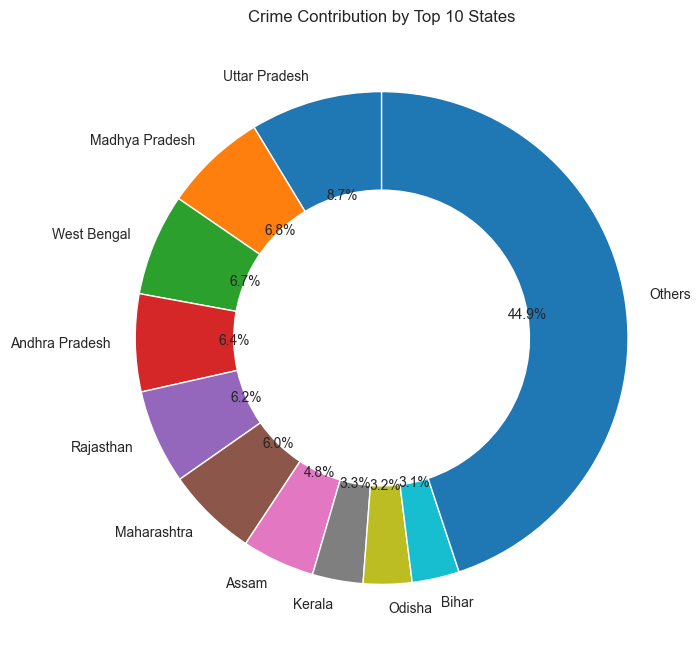

In [39]:
# DonutChart
labels = list(top10_states['State']) + ['Others']

sizes = list(top10_states['contribution%']) + [others_contribution]

plt.figure(figsize=(10,8))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4}
)

plt.title('Crime Contribution by Top 10 States')

plt.show()

### Insights

- Uttar Pradesh contributed the highest share of total crime cases (~10.9%).

- The top 10 states together contributed nearly 69% of the total crime cases.

- This indicates that a significant portion of crimes is concentrated within a limited number of states.

## Conclusion

- Uttar Pradesh recorded the highest overall crime cases among all states.

- Domestic violence was the largest contributing crime category.

- Crime cases generally increased over the years, especially after 2012.

- Assault on women and domestic violence showed a moderate positive relationship (correlation ≈ 0.63).

- A significant share of total crime cases was concentrated within the top 10 states.

- Some northeastern and union territory regions reported comparatively lower crime counts.

## Future Scope

- Population-normalized crime rate analysis can provide more accurate comparisons.

- Predictive modeling can be applied to forecast future crime trends.

- Geographic visualization using maps can improve regional analysis.